# Premier tests

In [1]:
import torch
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

True
NVIDIA A100 80GB PCIe


In [106]:
from transformers import AutoConfig

config = AutoConfig.from_pretrained("HuggingFaceTB/SmolLM3-3B")
print(config.hidden_size)
print(config.num_attention_heads)
print(config.num_hidden_layers)

2048
16
36


## Avec vllm pour l'inférence

- dtype:"bfloat16" : 
    - Brain Float 16 : moitier mem que float32 , même range dynamique
    - 2 byte / param -> 3B*2 ~ 6 gb
- gpu_memory_utilization=0.1 : limite l'utilisation du gpu à 10% ~ 8gb
- max_model_len=4096 : limite la taille des buffers du KV cache

In [ ]:
from vllm import LLM, SamplingParams

llm = LLM(
    model="HuggingFaceTB/SmolLM3-3B",
    dtype="bfloat16",
    gpu_memory_utilization=0.1,
    max_model_len=4096
)

INFO 03-04 09:22:51 [utils.py:223] non-default args: {'dtype': 'bfloat16', 'max_model_len': 4096, 'gpu_memory_utilization': 0.1, 'disable_log_stats': True, 'model': 'HuggingFaceTB/SmolLM3-3B'}
INFO 03-04 09:22:52 [model.py:529] Resolved architecture: SmolLM3ForCausalLM
INFO 03-04 09:22:52 [model.py:1549] Using max model len 4096
INFO 03-04 09:22:52 [scheduler.py:224] Chunked prefill is enabled with max_num_batched_tokens=8192.
(EngineCore_DP0 pid=2409702) INFO 03-04 09:22:53 [core.py:97] Initializing a V1 LLM engine (v0.16.0) with config: model='HuggingFaceTB/SmolLM3-3B', speculative_config=None, tokenizer='HuggingFaceTB/SmolLM3-3B', skip_tokenizer_init=False, tokenizer_mode=auto, revision=None, tokenizer_revision=None, trust_remote_code=False, dtype=torch.bfloat16, max_seq_len=4096, download_dir=None, load_format=auto, tensor_parallel_size=1, pipeline_parallel_size=1, data_parallel_size=1, disable_custom_all_reduce=False, quantization=None, enforce_eager=False, enable_return_routed_ex

Loading safetensors checkpoint shards:   0% Completed | 0/2 [00:00<?, ?it/s]


(EngineCore_DP0 pid=2409702) INFO 03-04 09:23:39 [default_loader.py:293] Loading weights took 34.34 seconds
(EngineCore_DP0 pid=2409702) INFO 03-04 09:23:40 [gpu_model_runner.py:4221] Model loading took 5.83 GiB memory and 39.335521 seconds
(EngineCore_DP0 pid=2409702) INFO 03-04 09:23:55 [backends.py:916] Using cache directory: /home/thomas/.cache/vllm/torch_compile_cache/681b965a0c/rank_0_0/backbone for vLLM's torch.compile
(EngineCore_DP0 pid=2409702) INFO 03-04 09:23:55 [backends.py:976] Dynamo bytecode transform time: 13.83 s
(EngineCore_DP0 pid=2409702) INFO 03-04 09:24:00 [backends.py:351] Cache the graph of compile range (1, 8192) for later use
(EngineCore_DP0 pid=2409702) INFO 03-04 09:24:04 [backends.py:368] Compiling a graph for compile range (1, 8192) takes 4.44 s
(EngineCore_DP0 pid=2409702) INFO 03-04 09:24:04 [monitor.py:34] torch.compile takes 18.28 s in total
(EngineCore_DP0 pid=2409702) INFO 03-04 09:24:06 [gpu_worker.py:373] Available KV cache memory: 0.85 GiB
(Engin

Capturing CUDA graphs (mixed prefill-decode, PIECEWISE): 100%|██████████| 51/51 [00:03<00:00, 13.81it/s]
Capturing CUDA graphs (decode, FULL): 100%|██████████| 35/35 [00:02<00:00, 16.53it/s]


(EngineCore_DP0 pid=2409702) INFO 03-04 09:24:13 [gpu_model_runner.py:5246] Graph capturing finished in 7 secs, took 0.71 GiB
(EngineCore_DP0 pid=2409702) INFO 03-04 09:24:13 [core.py:278] init engine (profile, create kv cache, warmup model) took 32.35 seconds
INFO 03-04 09:24:14 [llm.py:355] Supported tasks: ['generate']


In [12]:
params = SamplingParams(temperature=0.8, top_p=0.95, max_tokens=200)


In [ ]:
prompt = "What is the capital of France ? The first word of your response should be the answer"
outputs = llm.generate(prompt, params)

print(outputs[0].outputs[0].text)

Adding requests:   0%|          | 0/1 [00:00<?, ?it/s]

Processed prompts:   0%|          | 0/1 [00:00<?, ?it/s, est. speed input: 0.00 toks/s, output: 0.00 toks/s]

, and the response should include the location of the capital within the country.

The capital of France is Paris, which is located in Île-de-France region.


In [28]:
print(outputs[0].outputs[0].finish_reason)

stop


## Avec AutoModelCausalLM pour l'inférence

In [1]:
from transformers import AutoModelForCausalLM, AutoTokenizer
import torch

model_name = "HuggingFaceTB/SmolLM3-3B"
device = "cuda"  # for GPU usage or "cpu" for CPU usage

# load the tokenizer and the model
tokenizer = AutoTokenizer.from_pretrained(model_name)

In [2]:
model = AutoModelForCausalLM.from_pretrained(
    model_name,
    dtype=torch.bfloat16 
).to(device)

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

In [ ]:
# prepare the model input
prompt = "What is the capital of France ?"
messages = [
    {"role": "system", "content":"Answer with one word./no_think"},
    #{"role": "system", "content":"Speak like a pirat./no_think"},
    {"role": "user", "content": prompt}
]

text = tokenizer.apply_chat_template(
    messages,
    tokenize=False,
    add_generation_prompt=True,
    enable_thinking=False
)
model_inputs = tokenizer([text], return_tensors="pt").to(model.device)


In [28]:
# Generate the output
generated_ids = model.generate(**model_inputs, max_new_tokens=100)

# Get and decode the output
output_ids = generated_ids[0][len(model_inputs.input_ids[0]) :]
print(tokenizer.decode(output_ids, skip_special_tokens=True))


Arr, me hearty! The capital o' France be Paris, a grand city with lots o' history and beauty!


## Test : récupérer les hidden states du modèle, voir à partir de quelle couche la réponse apparait

In [3]:
from transformers import AutoModelForCausalLM, AutoTokenizer
import torch

model_name = "HuggingFaceTB/SmolLM3-3B"
device = "cuda"  # for GPU usage or "cpu" for CPU usage

# load the tokenizer and the model
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForCausalLM.from_pretrained(
    model_name,
    dtype=torch.bfloat16 
).to(device)

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

SmolLM utilise le flag /no_think pour désactiver le mode réflexion long

In [9]:
def remove_skiplines(stri):
    return stri.replace("\n","\\n")

def remove_spaces(stri):
    return stri.replace(" ", "").lower()

def display_top_tokens(prompt, expected_next, start_layer=30, end_layer=37, top_k=20, model=model, tokenizer=tokenizer):
    # text = tokenizer.apply_chat_template(
    #    prompt,
    #    tokenize=False,
    #    add_generation_prompt=True,
    #    enable_thinking=False
    # )
    inputs = tokenizer(prompt, return_tensors="pt").to(model.device)
    with torch.no_grad():
        outputs = model(**inputs,output_hidden_states=True)
    hidden_states = outputs.hidden_states

    lm_head = model.lm_head
    #final_ln = model.model.norm
    for i, h in enumerate(hidden_states[start_layer:], start=start_layer):
        last_token_hidden = h[:, -1, :]  

        #last_token_hidden = final_ln(last_token_hidden)

        logits = lm_head(last_token_hidden)
        probs = torch.softmax(logits, dim=-1)

        top_probs, top_token_ids = torch.topk(probs, top_k, dim=-1)
        #decoded_tokens = [tokenizer.decode([tid.item()]) for tid in top_token_ids[0]]
        decoded_tokens = []
        for tid in top_token_ids[0]:
            decoded_token = tokenizer.decode([tid.item()])
            #print(remove_spaces(decoded_token))
            if(tid.item() == tokenizer.encode(expected_next)[0] or remove_spaces(decoded_token) == remove_spaces(expected_next)):
                print(f"\n /!\\ ALERT : {expected_next} detected /!\\ \n")
            decoded_tokens.append(decoded_token)

        probs_list = [p.item() for p in top_probs[0]]
        topk_str = ", ".join([f'"{remove_skiplines(tok)}": {prob:.4f}' 
                            for tok, prob in zip(decoded_tokens, probs_list)])
        print(f"Layer {i}: [{topk_str}]")

In [52]:
# prepare the model input
prompt = "The name of the capital of Denmark is"
prompt2 = "The capital of France is "
messages = [
    {"role": "system", "content":"/no_think"},
    {"role": "user", "content": prompt}
]
expected = "Copenhagen"

display_top_tokens(prompt, expected, start_layer=26, top_k=5)

Layer 26: ["<|end_of_text|>": 0.0178, " "": 0.0118, " ": 0.0104, " “": 0.0095, " <": 0.0092]
Layer 27: ["<|end_of_text|>": 0.0197, " “": 0.0112, " <": 0.0108, ":": 0.0108, " *": 0.0090]
Layer 28: [" capital": 0.0400, "<|end_of_text|>": 0.0161, " "": 0.0118, " *": 0.0098, " “": 0.0089]
Layer 29: [" capital": 0.0933, " Capital": 0.0115, "<|end_of_text|>": 0.0092, " "": 0.0092, " “": 0.0089]
Layer 30: [" capital": 0.1094, " often": 0.0184, " "": 0.0135, " “": 0.0131, " not": 0.0082]

 /!\ ALERT : Copenhagen detected /!\ 

Layer 31: [" capital": 0.0481, " Copenhagen": 0.0134, " often": 0.0129, " unique": 0.0098, " “": 0.0065]
Layer 32: [" "": 0.0525, " often": 0.0383, " “": 0.0281, " C": 0.0193, " D": 0.0155]
Layer 33: [" "": 0.1475, " C": 0.1387, " “": 0.0698, " often": 0.0291, " ": 0.0199]
Layer 34: [" C": 0.0320, " often": 0.0208, " slammed": 0.0118, " Christian": 0.0089, " inform": 0.0089]
Layer 35: [" derp": 0.0588, " neigh": 0.0552, " _______,": 0.0356, "...": 0.0278, " often": 0.026

Paris est détecté parmis les top 20 token seulement à la couche 31/36

## Généraliser le test avec différent prompts (les pays et capitales du monde)

In [1]:
import pandas as pd
from transformers import AutoModelForCausalLM, AutoTokenizer
import torch
import numpy as np
from tqdm import tqdm
import plotly.express as px

model_name = "HuggingFaceTB/SmolLM3-3B"
device = "cuda"
df_path = "data/countries.csv"

In [2]:
# Creat Pandas dataframe to Columns Prompt and Label such as {Prompt : "The capital of France is", Label : "Paris"}
def generate_country_capital_prompts(file_name):
    df = pd.read_csv(file_name)
    prompt_df = df[["Country Name", "Capital"]].copy()
    prompt_df["Country Name"] = "The capital of " + prompt_df["Country Name"] + " is"
    prompt_df.rename(columns={'Country Name': 'Prompt', 'Capital': 'Label'}, inplace=True)
     
    return prompt_df

In [3]:
df = generate_country_capital_prompts(df_path)
df.head()

,Prompt,Label
0,The capital of Afghanistan is,Kabul
1,The capital of Albania is,Tirana
2,The capital of Algeria is,Algiers
3,The capital of Andorra is,Andorra la Vella
4,The capital of Angola is,Luanda


In [4]:
def load_model(model_name="HuggingFaceTB/SmolLM3-3B", device="cuda"):
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    model = AutoModelForCausalLM.from_pretrained(
        model_name,
        dtype=torch.bfloat16 
    ).to(device)

    return tokenizer, model

In [63]:
# Returns the hidden states of the residual stream after each layer (36)
def get_hidden_states(model, tokenizer, prompt, think_flag=0):
    think_str = "/no_think"
    if(think_flag):
        think_str= "/think"

    messages = [
        {"role": "system", "content":"Answer with one word.{think_str}"},
        {"role": "user", "content": prompt}
    ]

    text = tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True,
        enable_thinking=False
    )
    inputs = tokenizer([text], return_tensors="pt").to(model.device)
    with torch.no_grad():
        outputs = model(
            **inputs,
            output_hidden_states=True,
        )   

    return outputs.hidden_states

In [ ]:
# Returns the number of the first layer in which the right token is detected (label), the decoded token and its probability 
# for the top_k tokens or -1, 0
def first_layer_detection(model, tokenizer, hidden_states, label, top_k):
    lm_head = model.lm_head
    final_ln = model.model.norm

    for i, h in enumerate(hidden_states[1:], start=1):
        last_token_hidden = h[:, -1, :]  
        last_token_hidden = model.model.norm(last_token_hidden)

        logits = model.lm_head(last_token_hidden)
        probs = torch.softmax(logits, dim=-1)

        top_probs, top_token_ids = torch.topk(probs, top_k, dim=-1)

        for j, tid in enumerate(top_token_ids[0], start=0):
            decoded_token = tokenizer.decode([tid.item()])
            encoded_capital = tokenizer.encode(label)[0]
            if(tid.item() == encoded_capital):
                prob = top_probs[0][j]
                return i, prob

    return -1, 0
    

In [86]:
from tqdm import tqdm

# Analysis : from which layer of the model the right label starts appearing
def layer_analysis(model, tokenizer, df, nb_layers=36, top_k=20):

    layers_count = [0 for _ in range(nb_layers+1)]
    not_found_count = 0

    for row in tqdm(df.itertuples(), total=len(df)):
        #print(f"Prompt : {row.Prompt}, Label : {row.Label}")
        hidden_states = get_hidden_states(model, tokenizer, row.Prompt)
        layer, proba = first_layer_detection(model, tokenizer, hidden_states, row.Label, top_k)

        if(layer >= 1 and layer <= nb_layers-1):
            layers_count[layer] += 1
        else:
            not_found_count += 1

    return layers_count, not_found_count, nb_layers, top_k


In [87]:
import matplotlib.pyplot as plt

def plot_layer_analysis(layers_count, not_found_count, nb_layers, top_k):
    layers = [i for i in range(1,nb_layers+2)]
    layers_count[nb_layers] = not_found_count
    
    colors = ['skyblue'] * (len(layers_count) - 1) + ['red'] 

    plt.bar(layers, layers_count, color=colors)
    plt.xlabel('Couches de smolLM3')
    plt.ylabel('Bon token detecté', color='skyblue')
    plt.title(f'A partir de quelle couche de smolLM3 le bon token est détecté parmis le top {top_k}')
    plt.legend("")
    plt.text(0, -50, f"Proportion de capitales non trouvées : {not_found_count} / {len(df)}", color='red')
    plt.show()

In [5]:
df = generate_country_capital_prompts(df_path)
tokenizer, model = load_model()

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

In [88]:
ret = layer_analysis(model, tokenizer, df)

100%|██████████| 196/196 [00:23<00:00,  8.24it/s]


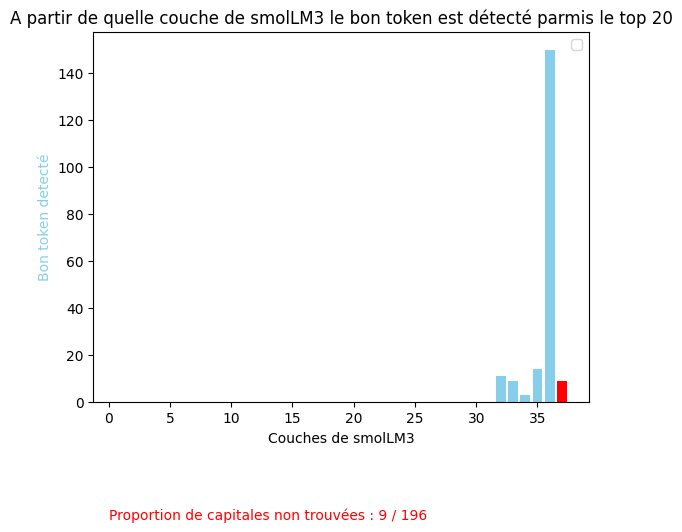

In [89]:
plot_layer_analysis(*ret)

## Test tokenization de Copenhagen

In [93]:
text = "Copenhagen"
tokens = tokenizer.encode(text)
print("Token IDs:", tokens)

for t in tokens:
    print(f"{t} -> \"{tokenizer.decode([t])}\"")

Token IDs: [34, 45929]
34 -> "C"
45929 -> "openhagen"


## Vizu des TOP 5 tokens par couche

In [ ]:
# Returns the hidden states of the residual stream after each layer (36)
def get_hidden_states_from_raw_prompt(model, tokenizer, prompt):
    inputs = tokenizer(prompt, return_tensors="pt").to(model.device)
    with torch.no_grad():
        outputs = model(
            **inputs,
            output_hidden_states=True,
        )   
    return outputs.hidden_states


def top_k_per_layer(model, tokenizer, hidden_states, label, layers, top_k):
    return_top_k = np.zeros((layers[1]-layers[0]+1, top_k))
    for i, h in enumerate(hidden_states[layers[0]:layers[1]+1], start=0):

        last_token_hidden = h[:, -1, :]
        logits = model.lm_head(last_token_hidden)
        probs = torch.softmax(logits, dim=-1)

        top_probs, top_token_ids = torch.topk(probs, top_k, dim=-1)

        for j, tid in enumerate(top_token_ids[0], start=0):
            decoded_token = tokenizer.decode([tid.item()])
            encoded_label = tokenizer.encode(label)[0]
            if(tid.item() == encoded_label or remove_spaces(decoded_token) == remove_spaces(label)):
                return_top_k[i, j] += 1
                #print(f"Label {label} trouvé pour pays {i}, TOP {j} !")

    return return_top_k
    

def topk_analysis(model, tokenizer, df, layers, top_k):

    nb_layers = layers[1] - layers[0] +1

    global_topk_cout = np.zeros((nb_layers, top_k))

    for row in tqdm(df.itertuples(), total=len(df)):
        #print(f"Prompt : {row.Prompt}, Label : {row.Label}")
        hidden_states = get_hidden_states_from_raw_prompt(model, tokenizer, row.Prompt)
        topk_count = top_k_per_layer(model, tokenizer, hidden_states, row.Label, layers=layers, top_k=top_k)

        global_topk_cout += topk_count

    return global_topk_cout, layers, top_k


def plot_topk_analysis(data, layers, top_k):

    x = np.arange(layers[0], layers[1]+1)

    # convert to long format
    df = pd.DataFrame(data, columns=[f"TOP {i+1}" for i in range(top_k)])
    df["Layers"] = x
    df = df.melt(id_vars="Layers", var_name="Token", value_name="Number of correct token")

    fig = px.bar(
        df,
        x="Layers",
        y="Number of correct token",
        color="Token",
        barmode="group",
        color_discrete_sequence=px.colors.qualitative.Set2
    )

    fig.show()

In [91]:
data, layers, top_k = topk_analysis(model, tokenizer, df, layers=(26,36), top_k=5)

100%|██████████| 196/196 [00:12<00:00, 15.46it/s]


In [92]:
plot_topk_analysis(data, layers, top_k)